<a href="https://colab.research.google.com/github/nepslor/teaching/blob/main/CAS_BDML/L1_bounty_source.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_fourier_descriptors(image_path, num_descriptors=20):
    # 1. Load image and find contours

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    print("Min:", img.min(), "Max:", img.max())
    # Threshold to ensure it's binary
    _, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)


    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    # Get the largest contour
    contour = max(contours, key=cv2.contourArea).reshape(-1, 2)

    # 2. Convert to complex time series: s(n) = x(n) + i*y(n)
    s = contour[:, 0] + 1j * contour[:, 1]

    # 3. Fourier Transform
    descriptors = np.fft.fft(s)

    # 4. Reconstruction (Low-pass filtering)
    # We zero out the high frequencies to see the "compressed" shape
    descriptors_truncated = np.copy(descriptors)
    descriptors_truncated[num_descriptors:-num_descriptors] = 0
    reconstructed_s = np.fft.ifft(descriptors_truncated)

    return contour, reconstructed_s, descriptors

In [2]:
contour, reconstructed, descriptors = get_fourier_descriptors('test.png', 400)

Min: 0 Max: 255


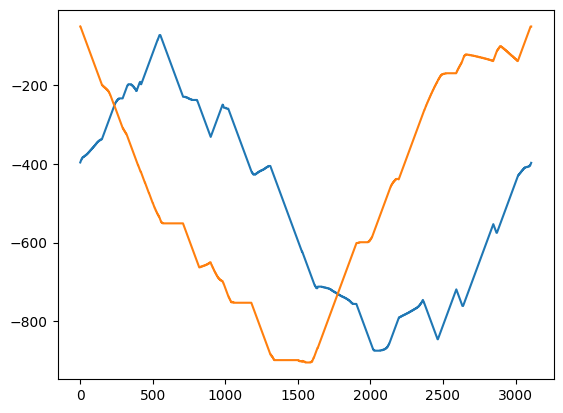

In [3]:
plt.plot(-contour)

In [4]:
data = np.tile(-contour.T, 10).T
noise = np.cumsum(np.random.randn(*data.shape)*5, 1)
data = data + noise

# add some missing values

random_vect = np.random.rand(data.shape[0])
random_convolved = np.convolve(random_vect, np.ones(26), mode='same')
missing_positions = random_vect < 0.65

data[missing_positions] = np.nan

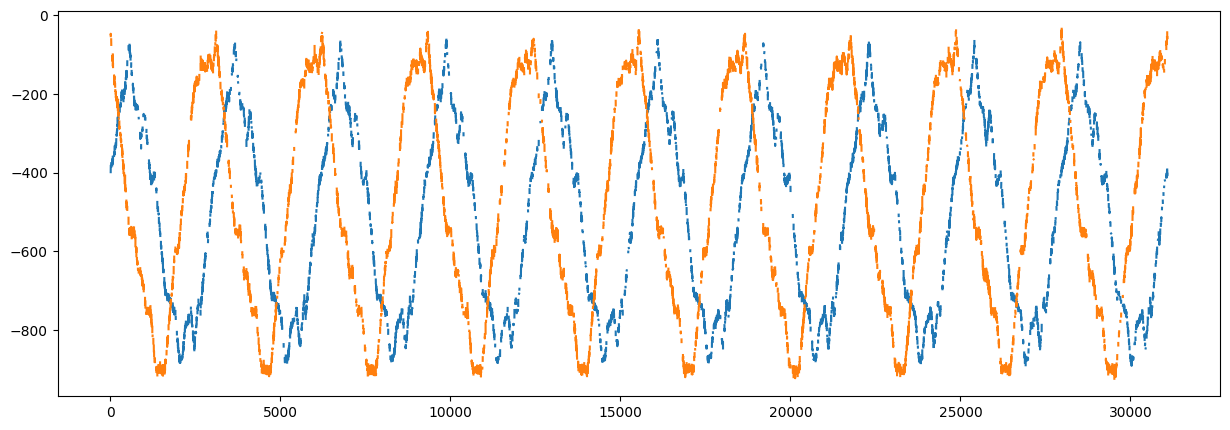

In [5]:
fig = plt.subplots(1, 1 , figsize=(15, 5))
plt.plot(data)

array([<Axes: >, <Axes: >], dtype=object)

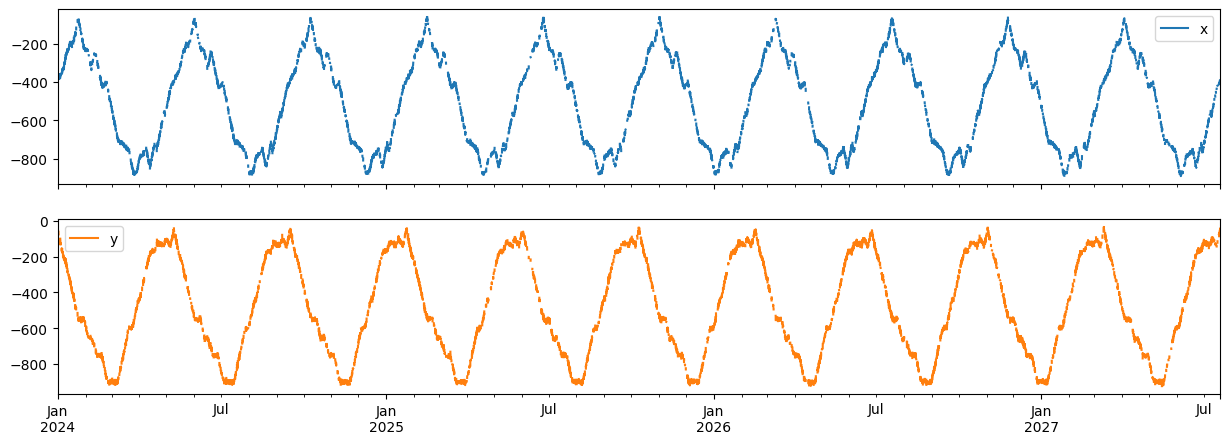

In [14]:
import pandas as pd
# create timestamped data
timestamps = pd.date_range(start='2024-01-01', periods=data.shape[0], freq='h')
df = pd.DataFrame(data, columns=['x', 'y'], index=timestamps)
df.plot(subplots=True, figsize=(15, 5))


<Axes: xlabel='x', ylabel='y'>

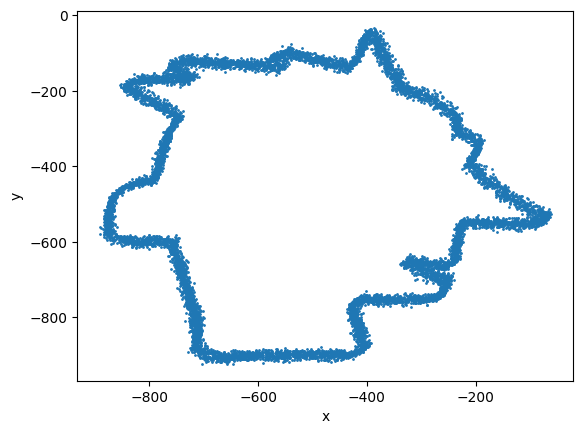

In [10]:
df.plot(kind='scatter', x='x', y='y', s=1)

In [16]:
df.to_pickle('bounty_data.pk')